# 04 — Forecast Model (Revised)

## Objective
Build, evaluate, and compare demand forecasting models for Club Piscine franchise inventory planning.
Replaces Prophet-only approach with a **tiered modeling strategy** anchored by a global XGBoost model.

## Architecture

| Tier | Model | Scope | Why |
|------|-------|-------|-----|
| **1 – Primary** | XGBoost (global) | All groups pooled into one model | Uses lag features (strongest signal), handles non-linear interactions, learns cross-store patterns |
| **2 – Comparison** | Prophet + regressors | High-volume series only (≥12 wks, avg > $2k) | Baseline comparison, interpretable components |
| **3 – Simple** | Last-4-week average | Low-volume / intermittent series | Avoids overfitting noisy data; reported separately |

## Key Changes from v1
- **XGBoost global model** replaces Prophet as primary (uses all NB03 features including lags)
- **Tiered group classification** — low-volume/intermittent series separated from accuracy summary
- **Expanding-window cross-validation** — more robust evaluation than single holdout
- **Feature importance analysis** — validates which features actually drive predictions
- **Correlated feature pruning** — addresses the 34 correlated pairs from NB03
- **Division-season features** generated here if missing from NB03

## Inputs
- `data/processed/modeling_dataset.csv` — from NB03

## Outputs
| File | Description |
|------|-------------|
| `forecast_output.csv` | Forward forecasts per store × division |
| `model_accuracy.csv` | wMAPE, RMSE, MAE per group per model |
| `baseline_comparison.csv` | XGBoost vs Prophet vs Naive vs MA |
| `forecast_output_by_store.csv` | Store-level aggregated forecasts |
| `inventory_gap_analysis.csv` | Forecast demand vs current inventory |
| `feature_importance.csv` | XGBoost feature importances |

## Evaluation
- **Primary metric:** wMAPE — `sum(|actual − forecast|) / sum(actual)`
- **Target:** Median wMAPE < 30% for Tier 1 high-volume divisions

## Data Limitation
Only 14 weeks of history (June–Sept 2025). Prototype only.
---

---
## Cell 1 — Imports and Configuration
---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import logging
from pathlib import Path
from scipy import stats

from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error
from sklearn.preprocessing import LabelEncoder

warnings.filterwarnings('ignore')
logging.getLogger('prophet').setLevel(logging.ERROR)
logging.getLogger('cmdstanpy').setLevel(logging.ERROR)

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.size'] = 10
plt.rcParams['figure.figsize'] = (14, 6)
sns.set_palette('husl')

PROJECT_ROOT   = Path('..')
DATA_RAW       = PROJECT_ROOT / 'data' / 'raw'
DATA_PROCESSED = PROJECT_ROOT / 'data' / 'processed'
FIGURES        = PROJECT_ROOT / 'reports' / 'figures'
FIGURES.mkdir(parents=True, exist_ok=True)

# ─────────────────────────────────────────────
# MODEL CONFIGURATION
# ─────────────────────────────────────────────
FORECAST_HORIZON   = 4       # Weeks to predict ahead (production)
EVAL_HORIZON       = 1       # 1 week holdout — tight but allows summer-only eval with 9 weeks
MIN_HISTORY        = 6       # Lowered for 14-week dataset
CONFIDENCE_LEVEL   = 0.95
N_CV_FOLDS         = 3       # Expanding-window CV folds

# ── Tiering thresholds ──
LOW_VOLUME_THRESHOLD = 200   # Avg weekly sales ($) below this → Tier 3
HIGH_CV_THRESHOLD    = 1.5   # CV above this → Tier 3
PROPHET_MIN_WEEKS    = 12
PROPHET_MIN_SALES    = 2000

# ── Store → City mapping (used if city column is missing) ──
STORE_TO_CITY = {
    'CP08': 'Longueuil',
    'CP37': 'Gatineau',
    'CP44': 'St-Constant',
    'CP48': 'Beloeil',
    'CP202': 'Nepean'
}

# ── Feature groups ──
GROUP_COLS = ['store_code', 'city', 'division_code']

LAG_FEATURES = [
    'sales_lag_1w', 'sales_lag_2w', 'sales_lag_4w',
    'sales_roll4_mean', 'sales_roll4_std'
]

SEASONALITY_FEATURES = [
    'sin_week_1', 'cos_week_1', 'sin_week_2', 'cos_week_2',
    'sin_month_1', 'cos_month_1'
]

CALENDAR_FEATURES = [
    'year_idx', 'quarter', 'week_of_yr', 'month',
    'has_holiday', 'n_holidays',
    'is_summer_peak', 'is_spring_opening', 'is_fall_closing'
]

WEATHER_FEATURES = [
    'avg_temp', 'total_precip', 'sunshine_hours',
    'rain_days', 'snow_days', 'bad_weather_days',
    'temp_above_20', 'temp_above_25',
    'cooling_degree_days', 'heating_degree_days',
    'avg_temp_dev_z', 'total_precip_dev_z'
]

PROPHET_REGRESSORS = [
    'avg_temp', 'bad_weather_days', 'snow_days', 'has_holiday',
    'is_summer_peak', 'cooling_degree_days'
]

print('✅ Configuration:')
print(f'   Forecast horizon     : {FORECAST_HORIZON} weeks')
print(f'   Eval holdout per fold: {EVAL_HORIZON} weeks × {N_CV_FOLDS} folds')
print(f'   Tiering: low-vol < ${LOW_VOLUME_THRESHOLD}/wk, high-CV > {HIGH_CV_THRESHOLD}')
print(f'   XGBoost features     : lags + seasonality + calendar + weather')
print(f'   Prophet regressors   : {PROPHET_REGRESSORS}')

✅ Configuration:
   Forecast horizon     : 4 weeks
   Eval holdout per fold: 1 weeks × 3 folds
   Tiering: low-vol < $200/wk, high-CV > 1.5
   XGBoost features     : lags + seasonality + calendar + weather
   Prophet regressors   : ['avg_temp', 'bad_weather_days', 'snow_days', 'has_holiday', 'is_summer_peak', 'cooling_degree_days']


---
## Cell 2 — Load Data, Ensure Schema, Enrich Features

Loads `modeling_dataset.csv` from NB03.
Rebuilds `city` from store mapping if missing.
Creates division-season interaction features if not in NB03 output.
Fills implicit zero-sale weeks and recomputes lags.
---

In [2]:
df = pd.read_csv(DATA_PROCESSED / 'modeling_dataset.csv')
df['week_ending'] = pd.to_datetime(df['week_ending'])

# ── Column diagnostics ──
print(f'Columns from modeling_dataset.csv ({len(df.columns)}):')
print(df.columns.tolist())

# ── Normalize column names ──
COLUMN_MAP = {
    'No. magasin': 'store_code', 'No magasin': 'store_code',
    'Division Code': 'division_code',
    'Montant de la ligne': 'sales',
    'Ville magasins': 'city', 'Ville': 'city',
}
df = df.rename(columns={k: v for k, v in COLUMN_MAP.items() if k in df.columns})

STORE_TO_CITY = {
    'CP08': 'Longueuil', 'CP37': 'Gatineau', 'CP44': 'St-Constant',
    'CP48': 'Beloeil', 'CP202': 'Nepean'
}
if 'city' not in df.columns:
    print('  → city missing — mapping from store_code')
    df['city'] = df['store_code'].map(STORE_TO_CITY)
else:
    df['city'] = df['city'].fillna(df['store_code'].map(STORE_TO_CITY))

for col in ['units', 'n_transactions']:
    if col not in df.columns:
        df[col] = 0

for req in ['store_code', 'division_code', 'sales', 'week_ending', 'city']:
    assert req in df.columns, f'Missing: {req}. Have: {df.columns.tolist()}'

df = df.sort_values(['store_code', 'division_code', 'week_ending']).reset_index(drop=True)

print(f'\nDataset: {df.shape[0]:,} rows × {df.shape[1]} cols')
print(f'Date range: {df["week_ending"].min().date()} → {df["week_ending"].max().date()}')
print(f'Stores: {sorted(df["store_code"].unique())}')
print(f'Divisions: {sorted(df["division_code"].unique())}')
print(f'Groups: {df.groupby(GROUP_COLS).ngroups}')

# ── Division-season features ──
POOL_DIVS    = ['PC', 'PI', 'CH', 'AP']
OUTDOOR_DIVS = ['GA', 'BQ', 'ME', 'SP']
FITNESS_DIVS = ['FI', 'HT']

if 'is_pool_div' not in df.columns:
    print('\n  → Creating division-season features')
    df['is_pool_div']    = df['division_code'].isin(POOL_DIVS).astype(int)
    df['is_outdoor_div'] = df['division_code'].isin(OUTDOOR_DIVS).astype(int)
    df['is_fitness_div'] = df['division_code'].isin(FITNESS_DIVS).astype(int)

if 'pool_x_summer' not in df.columns:
    summer = df['is_summer_peak'] if 'is_summer_peak' in df.columns else 0
    df['pool_x_summer']    = df['is_pool_div'] * summer
    df['outdoor_x_summer'] = df['is_outdoor_div'] * summer
    if 'avg_temp' in df.columns:
        df['pool_x_temp']    = df['is_pool_div'] * df['avg_temp']
        df['outdoor_x_temp'] = df['is_outdoor_div'] * df['avg_temp']

if 'temp_x_summer' not in df.columns and 'avg_temp' in df.columns:
    print('  → Creating weather × season interactions')
    summer = df['is_summer_peak'] if 'is_summer_peak' in df.columns else 0
    df['temp_x_summer'] = df['avg_temp'] * summer
    if 'total_precip' in df.columns:
        df['precip_x_summer'] = df['total_precip'] * summer
    if 'bad_weather_days' in df.columns:
        df['bad_wx_x_summer'] = df['bad_weather_days'] * summer

# ══════════════════════════════════════════════════════════════════
# PANEL FILL — for lag computation only, NOT for training/evaluation
# ══════════════════════════════════════════════════════════════════
# Tag original rows BEFORE panel fill
df['is_original'] = True

all_weeks = sorted(df['week_ending'].unique())
all_groups = df[GROUP_COLS].drop_duplicates()
full_index = all_groups.merge(pd.DataFrame({'week_ending': all_weeks}), how='cross')
n_before = len(df)
df = full_index.merge(df, on=GROUP_COLS + ['week_ending'], how='left')
df['is_original'] = df['is_original'].fillna(False)
df['sales'] = df['sales'].fillna(0)
df['units'] = df['units'].fillna(0)
df['n_transactions'] = df['n_transactions'].fillna(0)
n_synthetic = (~df['is_original']).sum()
print(f'\nPanel fill: {n_before:,} original + {n_synthetic:,} synthetic zeros = {len(df):,} total')

# Recompute lags on full panel (so lags don't skip gaps)
def recompute_lags(group):
    group = group.sort_values('week_ending').copy()
    group['sales_lag_1w']     = group['sales'].shift(1)
    group['sales_lag_2w']     = group['sales'].shift(2)
    group['sales_lag_4w']     = group['sales'].shift(4)
    group['sales_roll4_mean'] = group['sales'].shift(1).rolling(4, min_periods=2).mean()
    group['sales_roll4_std']  = group['sales'].shift(1).rolling(4, min_periods=2).std().fillna(0)
    return group

_parts = []
for _keys, _grp in df.groupby(GROUP_COLS):
    _parts.append(recompute_lags(_grp))
df = pd.concat(_parts, ignore_index=True)

# Fill weather/calendar NaNs for synthetic rows
fill_candidates = [c for c in df.columns if c in
    WEATHER_FEATURES + CALENDAR_FEATURES + SEASONALITY_FEATURES +
    ['month', 'year', 'week_of_yr', 'is_winter_off', 'province',
     'is_pool_div', 'is_outdoor_div', 'is_fitness_div',
     'pool_x_summer', 'outdoor_x_summer', 'pool_x_temp', 'outdoor_x_temp',
     'temp_x_summer', 'precip_x_summer', 'bad_wx_x_summer']]

for col in fill_candidates:
    if df[col].isna().any():
        df[col] = df.groupby(['store_code', 'week_ending'])[col].transform('first')
        if df[col].isna().any():
            df[col] = df[col].fillna(df[col].median())

# ══════════════════════════════════════════════════════════════════
# NOW DROP SYNTHETIC ROWS — they served their purpose for lag computation
# ══════════════════════════════════════════════════════════════════
df = df[df['is_original']].drop(columns=['is_original']).reset_index(drop=True)
print(f'After dropping synthetic rows: {len(df):,} rows (original data only)')
print(f'Final: {df.shape[0]:,} rows × {df.shape[1]} cols')


Columns from modeling_dataset.csv (53):
['week_ending', 'store_code', 'city', 'division_code', 'sales', 'units', 'n_transactions', 'avg_temp', 'max_temp', 'total_precip', 'sunshine_hours', 'rain_days', 'snow_days', 'bad_weather_days', 'n_holidays', 'has_holiday', 'month', 'week_of_yr', 'year', 'sin_week_1', 'cos_week_1', 'sin_week_2', 'cos_week_2', 'sin_month_1', 'cos_month_1', 'year_idx', 'quarter', 'is_summer_peak', 'is_spring_opening', 'is_fall_closing', 'is_winter_off', 'avg_temp_dev', 'avg_temp_dev_z', 'total_precip_dev', 'total_precip_dev_z', 'sunshine_hours_dev', 'sunshine_hours_dev_z', 'rain_days_dev', 'rain_days_dev_z', 'snow_days_dev', 'snow_days_dev_z', 'bad_weather_days_dev', 'bad_weather_days_dev_z', 'temp_above_20', 'temp_above_25', 'temp_below_0', 'cooling_degree_days', 'heating_degree_days', 'sales_lag_1w', 'sales_lag_2w', 'sales_lag_4w', 'sales_roll4_mean', 'sales_roll4_std']

Dataset: 1,333 rows × 53 cols
Date range: 2025-06-08 → 2025-09-14
Stores: ['CP08', 'CP202', '

---
## Cell 3 — Group Classification (Tier Assignment)

- **Tier 1 (XGBoost):** Sufficient history and stable enough for ML
- **Tier 2 (Prophet-eligible):** High-volume subset of Tier 1
- **Tier 3 (Simple baseline):** Low-volume or highly intermittent
- **Skip:** Insufficient history
---

In [3]:
group_stats = (
    df.groupby(GROUP_COLS)
    .agg(
        n_weeks=('week_ending', 'nunique'),
        n_nonzero=('sales', lambda x: (x > 0).sum()),
        avg_sales=('sales', 'mean'),
        median_sales=('sales', 'median'),
        std_sales=('sales', 'std'),
        total_sales=('sales', 'sum'),
        max_sales=('sales', 'max'),
        min_sales=('sales', 'min')
    )
    .reset_index()
)
group_stats['cv'] = group_stats['std_sales'] / group_stats['avg_sales'].clip(lower=1)
group_stats['zero_rate'] = 1 - (group_stats['n_nonzero'] / group_stats['n_weeks'])

# ── Assign tiers (tighter criteria) ──
group_stats['tier'] = 'skip'

mask_enough = (group_stats['n_weeks'] >= MIN_HISTORY + EVAL_HORIZON)

# Must have meaningful sales: avg > $500/wk AND >70% weeks with sales
mask_stable = (
    (group_stats['avg_sales'] >= 500) &
    (group_stats['zero_rate'] < 0.30) &
    (group_stats['cv'] <= 2.0)
)
group_stats.loc[mask_enough & mask_stable, 'tier'] = 'xgboost'

# Tier 3: has enough weeks but too sparse or low-volume
mask_tier3 = mask_enough & ~mask_stable
group_stats.loc[mask_tier3, 'tier'] = 'simple'

# Prophet eligibility: high-volume stable series
mask_prophet = (
    (group_stats['tier'] == 'xgboost') &
    (group_stats['n_weeks'] >= PROPHET_MIN_WEEKS) &
    (group_stats['avg_sales'] >= PROPHET_MIN_SALES) &
    (group_stats['cv'] <= 1.0)
)
group_stats['prophet_eligible'] = mask_prophet

print('=' * 70)
print('GROUP CLASSIFICATION')
print('=' * 70)
for tier in ['xgboost', 'simple', 'skip']:
    t = group_stats[group_stats['tier'] == tier]
    avg_s = t['avg_sales'].mean() if len(t) > 0 else 0
    avg_w = t['n_weeks'].mean() if len(t) > 0 else 0
    print(f'  {tier.upper():<12}: {len(t):>3} groups  '
          f'(avg sales: ${avg_s:>10,.0f}, avg weeks: {avg_w:>4.0f})')

n_prophet = group_stats['prophet_eligible'].sum()
print(f'  PROPHET     : {n_prophet:>3} groups (comparison model)')
print()

t1 = group_stats[group_stats['tier'] == 'xgboost'].sort_values('total_sales', ascending=False)
print('Tier 1 (XGBoost) groups:')
print(t1[['store_code', 'division_code', 'n_weeks', 'avg_sales', 'cv', 'zero_rate', 'prophet_eligible']].head(25).to_string(index=False))

t3 = group_stats[group_stats['tier'] == 'simple']
if len(t3) > 0:
    print(f'\nTier 3 (Simple): {len(t3)} groups')
    print(t3[['store_code', 'division_code', 'avg_sales', 'cv', 'zero_rate']].head(15).to_string(index=False))

print(f'\nSkipped: {(group_stats["tier"]=="skip").sum()} groups')

# Attach to main df
df = df.merge(group_stats[GROUP_COLS + ['tier', 'prophet_eligible', 'avg_sales', 'cv']],
              on=GROUP_COLS, how='left', suffixes=('', '_grp'))


GROUP CLASSIFICATION
  XGBOOST     :  82 groups  (avg sales: $     9,046, avg weeks:   13)
  SIMPLE      :  16 groups  (avg sales: $       293, avg weeks:   13)
  SKIP        :  13 groups  (avg sales: $     4,174, avg weeks:    3)
  PROPHET     :  49 groups (comparison model)

Tier 1 (XGBoost) groups:
store_code division_code  n_weeks    avg_sales       cv  zero_rate  prophet_eligible
      CP37            PC       15 41874.968000 0.489106        0.0              True
      CP37            AP       15 41228.004000 0.621114        0.0              True
      CP08            AP       15 38283.228667 0.573549        0.0              True
      CP48            AP       15 30548.759333 0.629169        0.0              True
      CP37            ME       15 30526.744000 0.403726        0.0              True
      CP08            ME       15 25535.786000 0.569779        0.0              True
     CP202            SP       12 31770.027500 0.704424        0.0              True
      CP48       

---
## Cell 4 — Correlated Feature Pruning

NB03 flagged 34 highly correlated feature pairs. Drop the weaker of each pair.
---

In [4]:
DIVISION_FEATURES = [c for c in df.columns if c.startswith(('is_pool', 'is_outdoor', 'is_fitness',
                                                             'pool_x', 'outdoor_x',
                                                             'temp_x', 'precip_x', 'bad_wx'))]
ALL_FEATURE_CANDIDATES = (
    LAG_FEATURES + SEASONALITY_FEATURES + CALENDAR_FEATURES +
    WEATHER_FEATURES + DIVISION_FEATURES
)
available_features = [f for f in ALL_FEATURE_CANDIDATES if f in df.columns]
print(f'Feature candidates: {len(available_features)}')

# ── Prune highly correlated pairs (|r| > 0.92) ──
df_numeric = df[available_features].dropna()
to_drop = set()

if len(df_numeric) > 100:
    corr_matrix = df_numeric.corr().abs()
    upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    target_corrs = df[['sales'] + available_features].corr()['sales'].abs()

    for col in upper.columns:
        high_corr_partners = upper.index[upper[col] > 0.92].tolist()
        for partner in high_corr_partners:
            if col in to_drop or partner in to_drop:
                continue
            if target_corrs.get(col, 0) >= target_corrs.get(partner, 0):
                to_drop.add(partner)
            else:
                to_drop.add(col)

    to_drop = list(to_drop)
    print(f'\nDropping {len(to_drop)} highly correlated features: {sorted(to_drop)}')
    available_features = [f for f in available_features if f not in to_drop]

FINAL_FEATURES = available_features.copy()
print(f'\n✅ Final feature set: {len(FINAL_FEATURES)} features')
for i, f in enumerate(FINAL_FEATURES):
    print(f'  {i+1:>2}. {f}')

Feature candidates: 42

Dropping 14 highly correlated features: ['cooling_degree_days', 'cos_month_1', 'cos_week_1', 'cos_week_2', 'has_holiday', 'is_summer_peak', 'pool_x_temp', 'rain_days', 'sales_lag_2w', 'sales_lag_4w', 'sin_month_1', 'sin_week_1', 'temp_x_summer', 'total_precip']

✅ Final feature set: 28 features
   1. sales_lag_1w
   2. sales_roll4_mean
   3. sales_roll4_std
   4. sin_week_2
   5. year_idx
   6. quarter
   7. week_of_yr
   8. month
   9. n_holidays
  10. is_spring_opening
  11. is_fall_closing
  12. avg_temp
  13. sunshine_hours
  14. snow_days
  15. bad_weather_days
  16. temp_above_20
  17. temp_above_25
  18. heating_degree_days
  19. avg_temp_dev_z
  20. total_precip_dev_z
  21. is_pool_div
  22. is_outdoor_div
  23. is_fitness_div
  24. pool_x_summer
  25. outdoor_x_summer
  26. outdoor_x_temp
  27. precip_x_summer
  28. bad_wx_x_summer


---
## Cell 5 — XGBoost Global Model with Expanding-Window CV

Single global model trained across ALL Tier 1 store-division groups.
Expanding-window CV: train on weeks 1→T, test on T+1→T+2, three folds.
---

In [5]:
df_t1 = df[df['tier'] == 'xgboost'].copy()

le_store = LabelEncoder()
le_div   = LabelEncoder()
df_t1['store_enc'] = le_store.fit_transform(df_t1['store_code'])
df_t1['div_enc']   = le_div.fit_transform(df_t1['division_code'])

XGBOOST_FEATURES = FINAL_FEATURES + ['store_enc', 'div_enc']
XGBOOST_FEATURES = [f for f in XGBOOST_FEATURES if f in df_t1.columns]

lag_cols_present = [c for c in LAG_FEATURES if c in df_t1.columns]
df_model = df_t1.dropna(subset=lag_cols_present).copy()

print(f'Tier 1 modeling data: {len(df_model):,} rows, {len(XGBOOST_FEATURES)} features')

sorted_weeks = sorted(df_model['week_ending'].unique())
n_weeks = len(sorted_weeks)
summer_weeks = [w for w in sorted_weeks if w.month <= 8]
sept_weeks   = [w for w in sorted_weeks if w.month >= 9]

print(f'\n{"="*70}')
print('EVALUATION STRATEGY')
print(f'{"="*70}')
print(f'Total weeks     : {n_weeks}')
print(f'Summer weeks    : {len(summer_weeks)} (Jun-Aug)')
print(f'September weeks : {len(sept_weeks)} (cliff, excluded from eval)')

# FORCE summer-only eval — this is the whole point
# With EVAL_HORIZON=1 and MIN_HISTORY=6, we need 7 summer weeks minimum
if len(summer_weeks) >= MIN_HISTORY + EVAL_HORIZON:
    eval_weeks = summer_weeks
    print(f'\n=> Using SUMMER-ONLY evaluation ({len(eval_weeks)} weeks)')
else:
    # True fallback: use all but explicitly warn
    eval_weeks = sorted_weeks
    print(f'\n=> WARNING: Not enough summer weeks, using all {len(eval_weeks)} weeks (includes Sep cliff)')

print(f'  Eval range: {eval_weeks[0].date()} -> {eval_weeks[-1].date()}')
print(f'  MIN_HISTORY={MIN_HISTORY}, EVAL_HORIZON={EVAL_HORIZON}, needed={MIN_HISTORY+EVAL_HORIZON}')

cv_results_all = []
cv_fold_metrics = []

for fold in range(N_CV_FOLDS):
    test_end_idx   = len(eval_weeks) - fold * EVAL_HORIZON
    test_start_idx = test_end_idx - EVAL_HORIZON
    if test_start_idx < MIN_HISTORY:
        print(f'  Fold {fold+1}: skipped (train would be {test_start_idx} weeks < {MIN_HISTORY})')
        continue

    train_wks = eval_weeks[:test_start_idx]
    test_wks  = eval_weeks[test_start_idx:test_end_idx]

    train_data = df_model[df_model['week_ending'].isin(train_wks)]
    test_data  = df_model[df_model['week_ending'].isin(test_wks)]

    if len(train_data) < 20 or len(test_data) < 3 or test_data['sales'].sum() < 50:
        print(f'  Fold {fold+1}: skipped (train={len(train_data)} rows, test={len(test_data)} rows)')
        continue

    X_train = train_data[XGBOOST_FEATURES].fillna(0)
    y_train = train_data['sales']
    X_test  = test_data[XGBOOST_FEATURES].fillna(0)
    y_test  = test_data['sales']

    xgb_model = XGBRegressor(
        n_estimators=200, max_depth=4, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.7, min_child_weight=10,
        reg_alpha=1.0, reg_lambda=3.0, gamma=0.2,
        random_state=42, verbosity=0
    )
    xgb_model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)

    preds = xgb_model.predict(X_test).clip(min=0)
    test_copy = test_data[GROUP_COLS + ['week_ending', 'sales']].copy()
    test_copy['pred'] = preds
    test_copy['fold'] = fold + 1
    cv_results_all.append(test_copy)

    fold_wmape = np.abs(y_test.values - preds).sum() / max(y_test.sum(), 1)
    fold_rmse  = np.sqrt(np.mean((y_test.values - preds)**2))
    cv_fold_metrics.append({
        'fold': fold+1, 'train_weeks': len(train_wks), 'test_weeks': len(test_wks),
        'train_rows': len(train_data), 'test_rows': len(test_data),
        'wMAPE': round(fold_wmape, 4), 'RMSE': round(fold_rmse, 2)
    })
    print(f'  Fold {fold+1}: train={len(train_wks)}wk ({len(train_data)} rows) -> '
          f'test={len(test_wks)}wk ({len(test_data)} rows)  '
          f'wMAPE={fold_wmape:.1%}  RMSE=${fold_rmse:,.0f}')

if len(cv_results_all) > 0:
    cv_results = pd.concat(cv_results_all, ignore_index=True)
    cv_metrics = pd.DataFrame(cv_fold_metrics)
    print(f'\n  Average across {len(cv_metrics)} folds: wMAPE={cv_metrics["wMAPE"].mean():.1%}  '
          f'RMSE=${cv_metrics["RMSE"].mean():,.0f}')
else:
    cv_results = pd.DataFrame(columns=GROUP_COLS + ['week_ending', 'sales', 'pred', 'fold'])
    cv_metrics = pd.DataFrame(columns=['fold', 'wMAPE', 'RMSE'])
    print('\n  Warning: No CV folds completed')


Tier 1 modeling data: 776 rows, 30 features

EVALUATION STRATEGY
Total weeks     : 11
Summer weeks    : 9 (Jun-Aug)
September weeks : 2 (cliff, excluded from eval)

=> Using SUMMER-ONLY evaluation (9 weeks)
  Eval range: 2025-07-06 -> 2025-08-31
  MIN_HISTORY=6, EVAL_HORIZON=1, needed=7
  Fold 1: train=8wk (611 rows) -> test=1wk (70 rows)  wMAPE=64.1%  RMSE=$4,249
  Fold 2: train=7wk (545 rows) -> test=1wk (66 rows)  wMAPE=76.7%  RMSE=$5,804
  Fold 3: train=6wk (467 rows) -> test=1wk (78 rows)  wMAPE=44.6%  RMSE=$5,792

  Average across 3 folds: wMAPE=61.8%  RMSE=$5,282


---
## Cell 6 — Per-Group Accuracy from XGBoost CV
---

In [6]:
xgb_group_metrics = []

for (store, city, div), grp in cv_results.groupby(GROUP_COLS):
    actuals = grp['sales'].values
    preds   = grp['pred'].values

    # Skip groups where test actuals sum to ~zero
    if len(actuals) < 2 or actuals.sum() < 10:
        continue

    abs_err = np.abs(actuals - preds)
    wmape   = abs_err.sum() / actuals.sum()   # clean denominator, no 1e-6 hack
    rmse    = np.sqrt(np.mean((actuals - preds)**2))
    mae     = np.mean(abs_err)
    bias    = np.mean(preds - actuals)
    xgb_group_metrics.append({
        'store_code': store, 'city': city, 'division_code': div,
        'wMAPE': round(wmape, 4), 'RMSE': round(rmse, 2),
        'MAE': round(mae, 2), 'Bias': round(bias, 2),
        'Avg_Sales': round(actuals.mean(), 2), 'model': 'XGBoost_Global'
    })

xgb_accuracy = pd.DataFrame(xgb_group_metrics)

print('=' * 80)
print('XGBOOST GLOBAL MODEL — PER-GROUP ACCURACY')
print('=' * 80)
print(f'Groups evaluated: {len(xgb_accuracy)}')
if len(xgb_accuracy) > 0:
    print(f'Overall wMAPE   : {xgb_accuracy["wMAPE"].mean():.1%}  (median: {xgb_accuracy["wMAPE"].median():.1%})')
    print(f'Overall RMSE    : ${xgb_accuracy["RMSE"].mean():,.0f}')
    print(f'Overall Bias    : ${xgb_accuracy["Bias"].mean():,.0f}')
    print()

    n_good = (xgb_accuracy['wMAPE'] < 0.30).sum()
    n_ok   = ((xgb_accuracy['wMAPE'] >= 0.30) & (xgb_accuracy['wMAPE'] < 0.60)).sum()
    n_poor = (xgb_accuracy['wMAPE'] >= 0.60).sum()
    print(f'Quality tiers:  ✓ Good (<30%): {n_good}  |  ~ OK (30-60%): {n_ok}  |  ⚠ Poor (>60%): {n_poor}')
    print()
    print('Best 10 groups:')
    print(xgb_accuracy.nsmallest(10, 'wMAPE')[['store_code','division_code','wMAPE','RMSE','Avg_Sales']].to_string(index=False))
    print()
    print('Worst 10 groups:')
    print(xgb_accuracy.nlargest(10, 'wMAPE')[['store_code','division_code','wMAPE','RMSE','Avg_Sales']].to_string(index=False))
else:
    print('⚠ No groups evaluated — check tiering thresholds')


XGBOOST GLOBAL MODEL — PER-GROUP ACCURACY
Groups evaluated: 74
Overall wMAPE   : 101.3%  (median: 66.1%)
Overall RMSE    : $3,553
Overall Bias    : $1,066

Quality tiers:  ✓ Good (<30%): 9  |  ~ OK (30-60%): 23  |  ⚠ Poor (>60%): 42

Best 10 groups:
store_code division_code  wMAPE    RMSE  Avg_Sales
     CP202            PC 0.1655 2516.01   14526.12
      CP08            AP 0.1662 3596.64   18766.67
     CP202            AS 0.1703  596.56    2887.83
      CP08            PC 0.1722 3178.77   16889.41
      CP48            BQ 0.1902  375.15    1688.47
      CP44            PC 0.2027 2795.03   11349.67
      CP37            PC 0.2217 7140.33   28333.29
      CP48            PC 0.2624 5808.39   16110.05
      CP37            ME 0.2759 7930.55   23432.20
      CP44            PA 0.3000  533.35    1762.90

Worst 10 groups:
store_code division_code  wMAPE     RMSE  Avg_Sales
      CP08            SE 7.9538  1415.42     173.32
      CP37            GA 5.6773 16190.57    2334.32
      CP08     

---
## Cell 7 — Feature Importance Analysis

Validates Nav's observation: demand momentum (lags/rolling) should dominate.
---

FEATURE IMPORTANCE (XGBoost Global Model)
  sales_roll4_mean               0.3362  █████████████████████████████████
  sales_lag_1w                   0.0844  ████████
  week_of_yr                     0.0602  ██████
  month                          0.0487  ████
  avg_temp                       0.0441  ████
  sunshine_hours                 0.0411  ████
  avg_temp_dev_z                 0.0384  ███
  total_precip_dev_z             0.0375  ███
  precip_x_summer                0.0364  ███
  div_enc                        0.0360  ███
  bad_weather_days               0.0294  ██
  pool_x_summer                  0.0292  ██
  is_pool_div                    0.0291  ██
  n_holidays                     0.0284  ██
  sales_roll4_std                0.0269  ██
  sin_week_2                     0.0268  ██
  bad_wx_x_summer                0.0250  ██
  heating_degree_days            0.0213  ██
  store_enc                      0.0209  ██
  year_idx                       0.0000  

Importance by feature group:

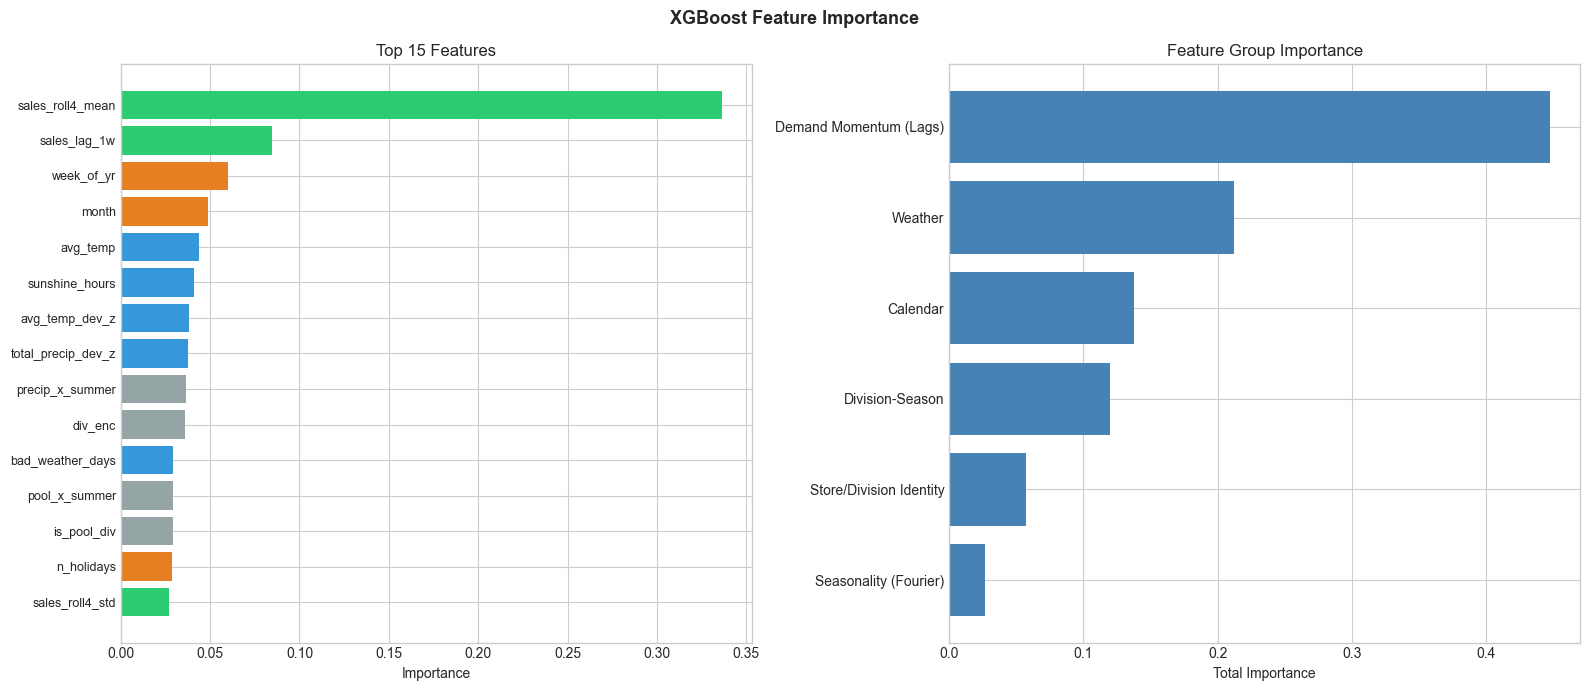


✅ Saved: feature_importance.png + feature_importance.csv


In [7]:
# Retrain final model on all available data
df_model_full = df_t1.dropna(subset=lag_cols_present).copy()
df_model_full['store_enc'] = le_store.transform(df_model_full['store_code'])
df_model_full['div_enc']   = le_div.transform(df_model_full['division_code'])

X_full = df_model_full[XGBOOST_FEATURES].fillna(0)
y_full = df_model_full['sales']

final_model = XGBRegressor(
    n_estimators=300, max_depth=5, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8, min_child_weight=10,
    reg_alpha=0.5, reg_lambda=2.0, gamma=0.1,
    random_state=42, verbosity=0
)
final_model.fit(X_full, y_full, verbose=False)

importance = pd.DataFrame({
    'feature': XGBOOST_FEATURES,
    'importance': final_model.feature_importances_
}).sort_values('importance', ascending=False)

print('=' * 70)
print('FEATURE IMPORTANCE (XGBoost Global Model)')
print('=' * 70)
for _, row in importance.head(20).iterrows():
    bar = '█' * int(row['importance'] * 100)
    print(f'  {row["feature"]:<30} {row["importance"]:.4f}  {bar}')

# Categorize by group
group_importance = {}
for feat, imp in zip(importance['feature'], importance['importance']):
    if feat in LAG_FEATURES:
        grp = 'Demand Momentum (Lags)'
    elif feat in SEASONALITY_FEATURES:
        grp = 'Seasonality (Fourier)'
    elif feat in CALENDAR_FEATURES:
        grp = 'Calendar'
    elif feat in WEATHER_FEATURES:
        grp = 'Weather'
    elif feat in DIVISION_FEATURES:
        grp = 'Division-Season'
    elif feat in ['store_enc', 'div_enc']:
        grp = 'Store/Division Identity'
    else:
        grp = 'Other'
    group_importance[grp] = group_importance.get(grp, 0) + imp

print('\nImportance by feature group:')
for grp, imp in sorted(group_importance.items(), key=lambda x: -x[1]):
    bar = '█' * int(imp * 50)
    print(f'  {grp:<30} {imp:.3f}  {bar}')

# Plot
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

top15 = importance.head(15)
colors = []
for f in top15['feature']:
    if f in LAG_FEATURES: colors.append('#2ecc71')
    elif f in WEATHER_FEATURES: colors.append('#3498db')
    elif f in CALENDAR_FEATURES: colors.append('#e67e22')
    elif f in SEASONALITY_FEATURES: colors.append('#9b59b6')
    else: colors.append('#95a5a6')

axes[0].barh(range(len(top15)), top15['importance'].values, color=colors)
axes[0].set_yticks(range(len(top15)))
axes[0].set_yticklabels(top15['feature'].values, fontsize=9)
axes[0].invert_yaxis()
axes[0].set_xlabel('Importance')
axes[0].set_title('Top 15 Features')

grps = sorted(group_importance.items(), key=lambda x: -x[1])
axes[1].barh([g[0] for g in grps], [g[1] for g in grps], color='steelblue')
axes[1].invert_yaxis()
axes[1].set_xlabel('Total Importance')
axes[1].set_title('Feature Group Importance')

plt.suptitle('XGBoost Feature Importance', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES / 'feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

importance.to_csv(DATA_PROCESSED / 'feature_importance.csv', index=False)
print('\n✅ Saved: feature_importance.png + feature_importance.csv')

---
## Cell 8 — Prophet Comparison (High-Volume Groups Only)

Prophet is NOT the primary model. This is for benchmarking against XGBoost.
---

In [8]:
from prophet import Prophet

def run_prophet(group_df, regressors, eval_weeks_list, eval_horizon, confidence):
    # Prophet eval using in-season holdout weeks
    ts = (group_df.sort_values('week_ending')
                  .rename(columns={'week_ending': 'ds', 'sales': 'y'}).copy())
    ts['y'] = ts['y'].clip(lower=0)
    avail_regs = [r for r in regressors if r in ts.columns and ts[r].notna().all()]

    ts_eval = ts[ts['ds'].isin(eval_weeks_list)].copy()
    if len(ts_eval) < MIN_HISTORY + eval_horizon:
        return None

    train = ts_eval.iloc[:-eval_horizon].copy()
    test  = ts_eval.iloc[-eval_horizon:].copy()

    if test['y'].sum() < 10:
        return None

    m = Prophet(yearly_seasonality=False, weekly_seasonality=False,
                daily_seasonality=False, interval_width=confidence,
                changepoint_prior_scale=0.1)
    for reg in avail_regs:
        m.add_regressor(reg, standardize=True)
    m.fit(train[['ds', 'y'] + avail_regs])

    future = m.make_future_dataframe(periods=eval_horizon, freq='W')
    future = future.merge(ts[['ds'] + avail_regs], on='ds', how='left')
    for reg in avail_regs:
        future[reg] = future[reg].fillna(future[reg].median())

    forecast = m.predict(future)
    preds = forecast.tail(eval_horizon)['yhat'].values.clip(min=0)
    actuals = test['y'].values

    abs_err = np.abs(actuals - preds)
    wmape = abs_err.sum() / max(actuals.sum(), 1)
    rmse  = np.sqrt(np.mean((actuals - preds)**2))
    mae   = np.mean(abs_err)
    bias  = np.mean(preds - actuals)
    return {'wMAPE': round(wmape, 4), 'RMSE': round(rmse, 2),
            'MAE': round(mae, 2), 'Bias': round(bias, 2),
            'Avg_Sales': round(actuals.mean(), 2)}

prophet_eligible = group_stats[group_stats['prophet_eligible'] == True]
prophet_results = []

print(f'Running Prophet on {len(prophet_eligible)} groups (in-season holdout)...')
print('-' * 75)

for _, row in prophet_eligible.iterrows():
    store, city, div = row['store_code'], row['city'], row['division_code']
    label = f'{store} ({city}) - {div}'
    grp = df[(df['store_code']==store) & (df['city']==city) &
             (df['division_code']==div)].copy()
    try:
        metrics = run_prophet(grp, PROPHET_REGRESSORS, eval_weeks, EVAL_HORIZON, CONFIDENCE_LEVEL)
        if metrics is None:
            print(f'  - {label:<40}  skipped (insufficient in-season data)')
            continue
        prophet_results.append({
            'store_code': store, 'city': city, 'division_code': div,
            **metrics, 'model': 'Prophet'
        })
        w = metrics['wMAPE']
        status = 'v' if w < 0.30 else '~' if w < 0.60 else '!'
        print(f'  {status} {label:<40}  wMAPE={w:.1%}  RMSE=${metrics["RMSE"]:,.0f}')
    except Exception as e:
        print(f'  x {label:<40}  ERROR: {e}')

prophet_accuracy = pd.DataFrame(prophet_results)
if len(prophet_accuracy) > 0:
    print(f'\nProphet median wMAPE (in-season): {prophet_accuracy["wMAPE"].median():.1%}')
else:
    print('\nNo Prophet models completed')


02:04:11 - cmdstanpy - INFO - Chain [1] start processing


Running Prophet on 49 groups (in-season holdout)...
---------------------------------------------------------------------------


02:04:13 - cmdstanpy - INFO - Chain [1] done processing
02:04:14 - cmdstanpy - INFO - Chain [1] start processing
02:04:14 - cmdstanpy - INFO - Chain [1] done processing
02:04:14 - cmdstanpy - INFO - Chain [1] start processing
02:04:14 - cmdstanpy - INFO - Chain [1] done processing


  ! CP08 (Longueuil) - AP                     wMAPE=90.5%  RMSE=$10,130
  ! CP08 (Longueuil) - AS                     wMAPE=100.0%  RMSE=$2,836


02:04:14 - cmdstanpy - INFO - Chain [1] start processing
02:04:14 - cmdstanpy - INFO - Chain [1] done processing
02:04:14 - cmdstanpy - INFO - Chain [1] start processing
02:04:14 - cmdstanpy - INFO - Chain [1] done processing


...

  ! CP48 (Beloeil) - IN                       wMAPE=100.0%  RMSE=$280
  ! CP48 (Beloeil) - LO                       wMAPE=889.7%  RMSE=$1,426


02:04:18 - cmdstanpy - INFO - Chain [1] start processing
02:04:18 - cmdstanpy - INFO - Chain [1] done processing
02:04:18 - cmdstanpy - INFO - Chain [1] start processing
02:04:18 - cmdstanpy - INFO - Chain [1] done processing


  ! CP48 (Beloeil) - ME                       wMAPE=100.0%  RMSE=$2,515
  ! CP48 (Beloeil) - PA                       wMAPE=100.0%  RMSE=$214


02:04:19 - cmdstanpy - INFO - Chain [1] start processing
02:04:19 - cmdstanpy - INFO - Chain [1] done processing


  ~ CP48 (Beloeil) - PC                       wMAPE=51.3%  RMSE=$6,314
  v CP48 (Beloeil) - PI                       wMAPE=16.1%  RMSE=$247

Prophet median wMAPE (in-season): 100.0%


---
## Cell 9 — Baseline Models + Full Comparison
---

In [9]:
baseline_results = []

for (store, city, div), grp in df[df['tier']=='xgboost'].groupby(GROUP_COLS):
    ts = grp.sort_values('week_ending')
    ts_eval = ts[ts['week_ending'].isin(eval_weeks)]
    if len(ts_eval) < MIN_HISTORY + EVAL_HORIZON:
        continue

    train = ts_eval.iloc[:-EVAL_HORIZON]
    test  = ts_eval.iloc[-EVAL_HORIZON:]
    actuals = test['sales'].values

    if actuals.sum() < 10:
        continue

    naive_pred = train['sales'].tail(min(4, len(train))).mean()
    naive_preds = np.full(len(actuals), naive_pred)
    naive_wmape = np.abs(actuals - naive_preds).sum() / actuals.sum()
    naive_rmse  = np.sqrt(np.mean((actuals - naive_preds)**2))

    ma_pred = train['sales'].mean()
    ma_preds = np.full(len(actuals), ma_pred)
    ma_wmape = np.abs(actuals - ma_preds).sum() / actuals.sum()
    ma_rmse  = np.sqrt(np.mean((actuals - ma_preds)**2))

    baseline_results.append({
        'store_code': store, 'city': city, 'division_code': div,
        'Naive_wMAPE': round(naive_wmape, 4), 'Naive_RMSE': round(naive_rmse, 2),
        'MA_wMAPE': round(ma_wmape, 4), 'MA_RMSE': round(ma_rmse, 2),
    })

baseline_df = pd.DataFrame(baseline_results)

comparison = baseline_df.copy()
if len(xgb_accuracy) > 0:
    comparison = comparison.merge(
        xgb_accuracy[GROUP_COLS + ['wMAPE', 'RMSE']].rename(
            columns={'wMAPE': 'XGB_wMAPE', 'RMSE': 'XGB_RMSE'}),
        on=GROUP_COLS, how='left')
if len(prophet_accuracy) > 0:
    comparison = comparison.merge(
        prophet_accuracy[GROUP_COLS + ['wMAPE', 'RMSE']].rename(
            columns={'wMAPE': 'Prophet_wMAPE', 'RMSE': 'Prophet_RMSE'}),
        on=GROUP_COLS, how='left')

print('=' * 80)
print('MODEL COMPARISON - IN-SEASON HOLDOUT (all models, same period)')
print('=' * 80)

models_all = {}
if 'XGB_wMAPE' in comparison.columns:
    models_all['XGBoost']  = comparison['XGB_wMAPE'].dropna()
models_all['Naive']        = comparison['Naive_wMAPE'].dropna()
models_all['Moving Avg']   = comparison['MA_wMAPE'].dropna()
if 'Prophet_wMAPE' in comparison.columns:
    models_all['Prophet']  = comparison['Prophet_wMAPE'].dropna()

for name, vals in models_all.items():
    print(f'  {name:<20}: mean={vals.mean():.1%}  median={vals.median():.1%}  (n={len(vals)})')

# Head-to-head where both exist
has_xgb = comparison['XGB_wMAPE'].notna() if 'XGB_wMAPE' in comparison.columns else pd.Series(False, index=comparison.index)
has_prophet = comparison['Prophet_wMAPE'].notna() if 'Prophet_wMAPE' in comparison.columns else pd.Series(False, index=comparison.index)
comp_common = comparison[has_xgb & has_prophet].copy()

if len(comp_common) > 0:
    print(f'\n  Head-to-head ({len(comp_common)} groups with both XGBoost and Prophet):')
    xgb_wins     = (comp_common['XGB_wMAPE'] < comp_common['Prophet_wMAPE']).sum()
    prophet_wins = (comp_common['Prophet_wMAPE'] < comp_common['XGB_wMAPE']).sum()
    print(f'    XGBoost wins: {xgb_wins}  |  Prophet wins: {prophet_wins}')

    detail = comp_common[['store_code', 'division_code', 'XGB_wMAPE', 'Prophet_wMAPE',
                           'Naive_wMAPE']].copy()
    detail['winner'] = detail.apply(
        lambda r: 'XGBoost' if r['XGB_wMAPE'] < r['Prophet_wMAPE'] else 'Prophet', axis=1)
    detail = detail.sort_values('XGB_wMAPE')
    print(f'\n  Per-group detail:')
    print(detail.to_string(index=False))

# Best model per group
def pick_best(row):
    candidates = {'Naive': row['Naive_wMAPE'], 'MA': row['MA_wMAPE']}
    if pd.notna(row.get('XGB_wMAPE')): candidates['XGBoost'] = row['XGB_wMAPE']
    if pd.notna(row.get('Prophet_wMAPE')): candidates['Prophet'] = row['Prophet_wMAPE']
    best = min(candidates, key=candidates.get)
    return best, candidates[best]

comparison[['best_model', 'best_wMAPE']] = comparison.apply(
    lambda r: pd.Series(pick_best(r)), axis=1)

print(f'\n{"=" * 80}')
print('BEST MODEL PER GROUP')
print('=' * 80)
print(comparison['best_model'].value_counts().to_string())
print(f'\nMedian best-of wMAPE: {comparison["best_wMAPE"].median():.1%}')

under_30 = comparison[comparison['best_wMAPE'] < 0.30]
under_50 = comparison[comparison['best_wMAPE'] < 0.50]
print(f'Groups with wMAPE < 30%: {len(under_30)}')
print(f'Groups with wMAPE < 50%: {len(under_50)}')
if len(under_30) > 0:
    print(under_30[['store_code', 'division_code', 'best_model', 'best_wMAPE']].to_string(index=False))


MODEL COMPARISON - IN-SEASON HOLDOUT (all models, same period)
  XGBoost             : mean=87.6%  median=63.9%  (n=69)
  Naive               : mean=304.6%  median=134.1%  (n=71)
  Moving Avg          : mean=428.1%  median=195.2%  (n=71)
  Prophet             : mean=218.7%  median=100.0%  (n=48)

  Head-to-head (48 groups with both XGBoost and Prophet):
    XGBoost wins: 28  |  Prophet wins: 20

  Per-group detail:
store_code division_code  XGB_wMAPE  Prophet_wMAPE  Naive_wMAPE  winner
     CP202            PC     0.1655         0.0996       0.7013 Prophet
      CP08            AP     0.1662         0.9049       1.4422 XGBoost
     CP202            AS     0.1703         0.6749       0.2396 XGBoost
      CP08            PC     0.1722         0.1216       0.5654 Prophet
      CP48            BQ     0.1902         0.1848       0.3753 Prophet
      CP44            PC     0.2027         0.0160       1.0730 Prophet
      CP37            PC     0.2217         0.1475       0.6111 Prophet
     

---
## Cell 10 — Tier 3: Simple Baselines for Low-Volume Series
---

In [10]:
tier3_results = []
tier3_groups = group_stats[group_stats['tier'] == 'simple']

for _, row in tier3_groups.iterrows():
    store, city, div = row['store_code'], row['city'], row['division_code']
    grp = df[(df['store_code']==store) & (df['city']==city) &
             (df['division_code']==div)].sort_values('week_ending')
    if len(grp) < MIN_HISTORY + EVAL_HORIZON:
        continue
    train = grp.iloc[:-EVAL_HORIZON]
    test  = grp.iloc[-EVAL_HORIZON:]
    actuals = test['sales'].values
    pred = train['sales'].tail(4).mean()
    preds = np.full(len(actuals), pred)
    wmape = np.abs(actuals - preds).sum() / max(np.abs(actuals).sum(), 1e-6)
    tier3_results.append({
        'store_code': store, 'city': city, 'division_code': div,
        'wMAPE': round(wmape, 4), 'Avg_Sales': round(row['avg_sales'], 2),
        'CV': round(row['cv'], 2), 'model': 'Simple_Avg'
    })

tier3_df = pd.DataFrame(tier3_results)
if len(tier3_df) > 0:
    print('=' * 70)
    print('TIER 3 — LOW-VOLUME / INTERMITTENT (reported separately)')
    print('=' * 70)
    print(f'Groups: {len(tier3_df)}, Median wMAPE: {tier3_df["wMAPE"].median():.1%}')
    print(tier3_df.sort_values('wMAPE').to_string(index=False))
else:
    print('No Tier 3 groups')

TIER 3 — LOW-VOLUME / INTERMITTENT (reported separately)
Groups: 16, Median wMAPE: 99.6%
store_code        city division_code        wMAPE  Avg_Sales   CV      model
      CP48     Beloeil            AZ 1.320000e-02     491.04 1.46 Simple_Avg
      CP37    Gatineau            DI 7.800000e-02      82.44 0.74 Simple_Avg
      CP08   Longueuil            AZ 8.980000e-02     462.48 2.16 Simple_Avg
      CP44 St-Constant            AZ 2.482000e-01     252.63 1.33 Simple_Avg
      CP48     Beloeil            MK 2.500000e-01       2.27 0.33 Simple_Avg
      CP48     Beloeil            SE 2.672000e-01     378.18 0.58 Simple_Avg
      CP48     Beloeil            AM 4.880000e-01     336.87 0.80 Simple_Avg
      CP37    Gatineau            SE 9.926000e-01     407.83 0.90 Simple_Avg
      CP08   Longueuil            MK 1.000000e+00      10.77 0.46 Simple_Avg
      CP37    Gatineau            MK 1.226300e+00     170.67 1.25 Simple_Avg
      CP44 St-Constant            AM 8.984900e+00     229.23 0.7

---
## Cell 11 — Production Forecast (Forward-Looking)

Recursive XGBoost forecast: predict t+1, feed back as lag input for t+2.
---

In [11]:
forecast_list = []
last_date = df['week_ending'].max()
forecast_dates = [last_date + pd.Timedelta(weeks=w) for w in range(1, FORECAST_HORIZON + 1)]

print(f'Forecast window: {forecast_dates[0].date()} → {forecast_dates[-1].date()}')

# ── Tier 1: XGBoost recursive ──
for (store, city, div), grp in df[df['tier']=='xgboost'].groupby(GROUP_COLS):
    grp = grp.sort_values('week_ending').copy()
    recent = grp.tail(4)
    last_row = grp.iloc[-1]

    for step, fdate in enumerate(forecast_dates):
        row = {}
        for f in XGBOOST_FEATURES:
            if f in ['sales_lag_1w', 'sales_lag_2w', 'sales_lag_4w',
                      'sales_roll4_mean', 'sales_roll4_std']:
                continue
            elif f == 'store_enc':
                row[f] = le_store.transform([store])[0]
            elif f == 'div_enc':
                row[f] = le_div.transform([div])[0]
            elif f == 'week_of_yr':
                row[f] = fdate.isocalendar()[1]
            elif f == 'month':
                row[f] = fdate.month
            elif f == 'quarter':
                row[f] = (fdate.month - 1) // 3 + 1
            elif f in last_row.index:
                row[f] = last_row[f]
            else:
                row[f] = 0

        # Recursive lags
        prev_forecasts = [r['Forecast_Sales'] for r in forecast_list
                          if r['store_code']==store and r['division_code']==div]
        sales_history = list(recent['sales'].values) + prev_forecasts

        row['sales_lag_1w'] = sales_history[-1] if len(sales_history) >= 1 else 0
        row['sales_lag_2w'] = sales_history[-2] if len(sales_history) >= 2 else 0
        row['sales_lag_4w'] = sales_history[-4] if len(sales_history) >= 4 else 0
        recent_4 = sales_history[-4:] if len(sales_history) >= 4 else sales_history
        row['sales_roll4_mean'] = np.mean(recent_4) if recent_4 else 0
        row['sales_roll4_std']  = np.std(recent_4) if len(recent_4) > 1 else 0

        X_pred = pd.DataFrame([row])[XGBOOST_FEATURES].fillna(0)
        pred = max(0, final_model.predict(X_pred)[0])

        forecast_list.append({
            'store_code': store, 'city': city, 'division_code': div,
            'Week': fdate, 'Forecast_Sales': round(pred, 2), 'model': 'XGBoost_Global'
        })

# ── Tier 3: Simple average ──
for (store, city, div), grp in df[df['tier']=='simple'].groupby(GROUP_COLS):
    avg = grp['sales'].tail(4).mean()
    for fdate in forecast_dates:
        forecast_list.append({
            'store_code': store, 'city': city, 'division_code': div,
            'Week': fdate, 'Forecast_Sales': round(max(0, avg), 2), 'model': 'Simple_Avg'
        })

forecast_df = pd.DataFrame(forecast_list)
forecast_df['Week'] = pd.to_datetime(forecast_df['Week'])

print(f'Forecast output: {len(forecast_df):,} rows')

forecast_store = (
    forecast_df.groupby(['store_code', 'city', 'Week'])
    .agg(Forecast_Sales=('Forecast_Sales', 'sum')).reset_index()
)
print('\nStore-level forecast:')
print(forecast_store.head(20).to_string(index=False))

Forecast window: 2025-09-21 → 2025-10-12
Forecast output: 392 rows

Store-level forecast:
store_code        city       Week  Forecast_Sales
      CP08   Longueuil 2025-09-21    28671.800337
      CP08   Longueuil 2025-09-28    30167.329928
      CP08   Longueuil 2025-10-05    27080.929518
      CP08   Longueuil 2025-10-12    18730.539595
     CP202      Nepean 2025-09-21    24204.430296
     CP202      Nepean 2025-09-28    19653.649488
     CP202      Nepean 2025-10-05    16727.560425
     CP202      Nepean 2025-10-12    14963.519944
      CP37    Gatineau 2025-09-21    27858.109337
      CP37    Gatineau 2025-09-28    28820.740326
      CP37    Gatineau 2025-10-05    24568.670212
      CP37    Gatineau 2025-10-12    14979.560258
      CP44 St-Constant 2025-09-21    25222.630365
      CP44 St-Constant 2025-09-28    25347.410419
      CP44 St-Constant 2025-10-05    22354.240323
      CP44 St-Constant 2025-10-12    25520.319470
      CP48     Beloeil 2025-09-21    20801.910035
      CP48

---
## Cell 12 — Inventory Gap Analysis
---

In [12]:
inventaire = pd.read_excel(DATA_RAW / 'Exemple_Table_Inventaire.xlsx')
inventaire['store_code'] = inventaire['Location Code'].str.extract(r'(CP\d+)', expand=False)

inv_summary = (
    inventaire.groupby(['store_code', 'Division Code'])
    .agg(qty_available=('Quantity Available', 'sum'),
         inventory_value=('Inventory Value', 'sum'))
    .reset_index().rename(columns={'Division Code': 'division_code'})
)

forecast_demand = (
    forecast_df.groupby(['store_code', 'division_code'])['Forecast_Sales']
    .sum().reset_index().rename(columns={'Forecast_Sales': 'forecast_demand_total'})
)

gap = forecast_demand.merge(inv_summary, on=['store_code', 'division_code'], how='left')
gap['inventory_value'] = gap['inventory_value'].fillna(0)
gap['qty_available']   = gap['qty_available'].fillna(0)
gap['demand_vs_stock'] = gap['forecast_demand_total'] - gap['inventory_value']
gap['gap_flag'] = gap['demand_vs_stock'].apply(
    lambda x: '⚠️ Potential gap' if x > 0 else '✅ OK')

print(f'INVENTORY GAP ANALYSIS (next {FORECAST_HORIZON} weeks)')
print(gap.sort_values('demand_vs_stock', ascending=False).head(25).to_string(index=False))

INVENTORY GAP ANALYSIS (next 4 weeks)
store_code division_code  forecast_demand_total  qty_available  inventory_value  demand_vs_stock         gap_flag
      CP44            HT           10381.869873            9.0          3940.14      6441.729873 ⚠️ Potential gap
     CP202            CH            7341.740112           -1.0          1070.00      6271.740112 ⚠️ Potential gap
      CP48            HT            9361.639893           12.0          4773.56      4588.079893 ⚠️ Potential gap
      CP08            SE            1775.990051            0.0             0.00      1775.990051 ⚠️ Potential gap
      CP08           INM            1573.760010            0.0             0.00      1573.760010 ⚠️ Potential gap
     CP202            LI            1441.920044           -3.0             0.00      1441.920044 ⚠️ Potential gap
      CP48            SE            1014.880000            0.0             0.00      1014.880000 ⚠️ Potential gap
      CP48           INM             954.880005   

---
## Cell 13 — Forecast Diagnostics
---

DIAGNOSTIC CHECKLIST

1. FORECAST BIAS: $1,066
   ⚠ Systematic over-prediction

2. MODEL VS BASELINES
   XGBoost median: 63.9%  |  Naive: 134.1%  |  MA: 195.2%
   ✓ PASS — XGBoost outperforms both baselines

3. RESIDUAL NORMALITY: p=0.0000

4. DATA SUFFICIENCY: 11 weeks
   Tier 1: 74, Tier 3: 16, Skipped: 13
   ⚠ Short history — directional forecasts only

5. FEATURE IMPORTANCE
   Lags: 0.447  |  Weather: 0.212
   ✓ Demand momentum > Weather (consistent with analysis)


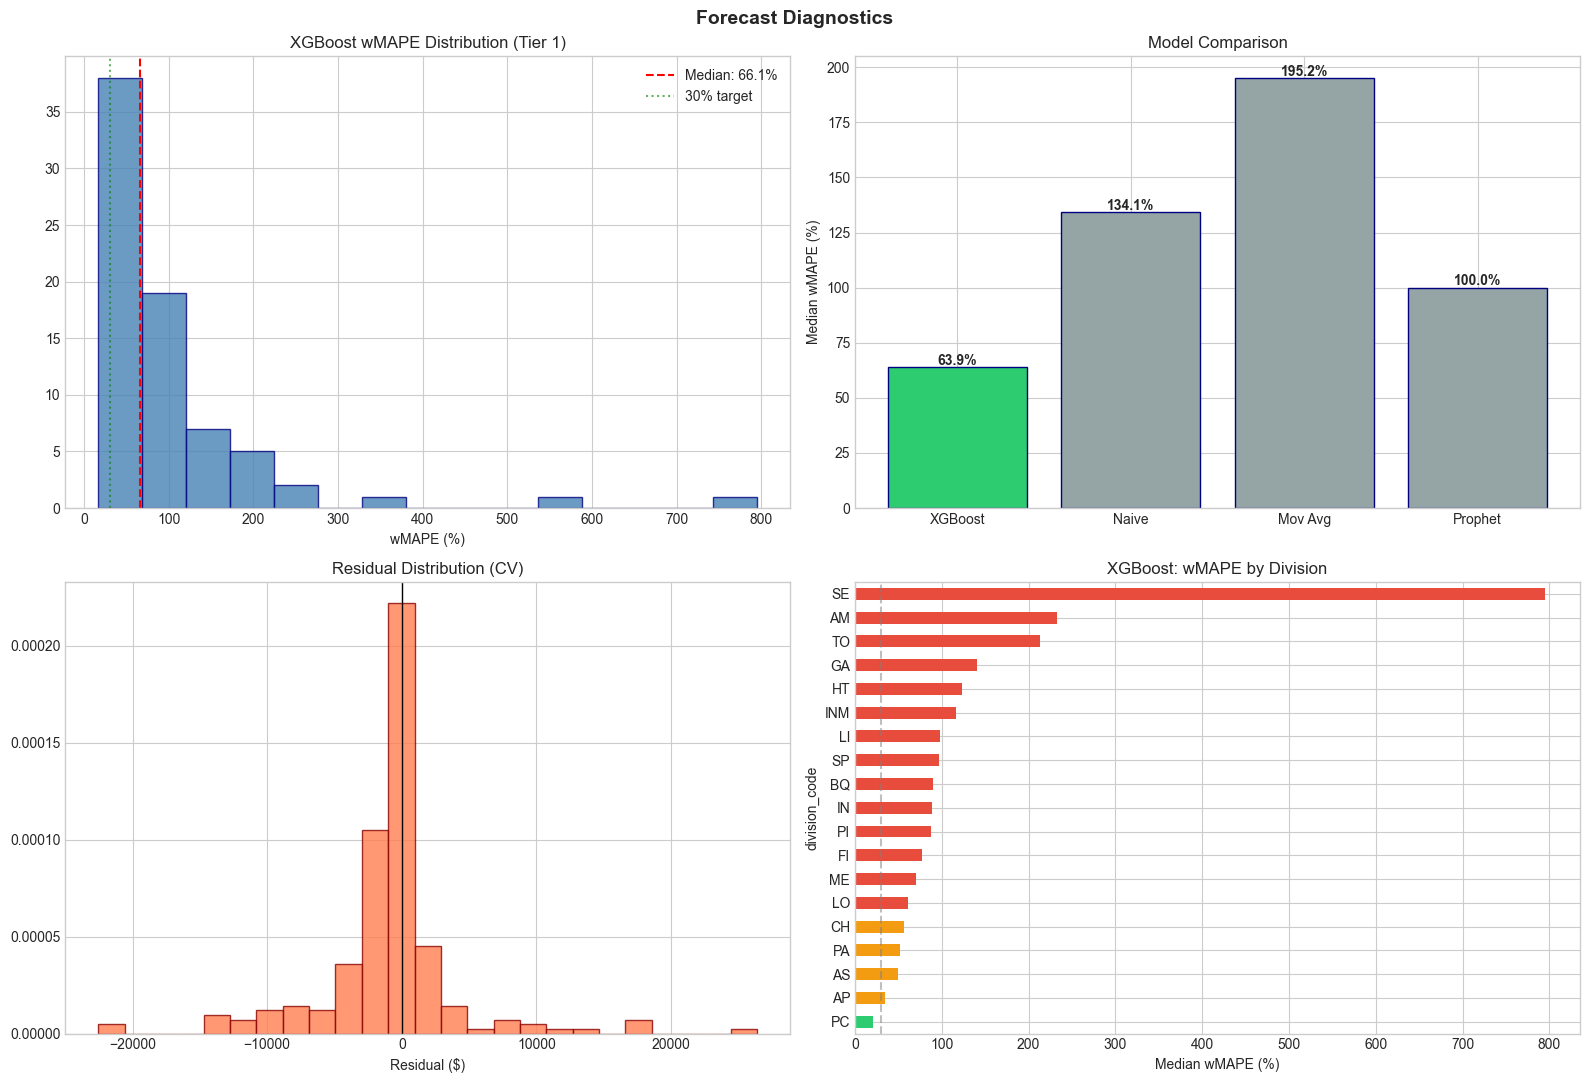


✅ Saved: forecast_diagnostics.png


In [13]:
print('=' * 80)
print('DIAGNOSTIC CHECKLIST')
print('=' * 80)

# 1. Bias
mean_bias = xgb_accuracy['Bias'].mean()
print(f'\n1. FORECAST BIAS: ${mean_bias:,.0f}')
if abs(mean_bias) < xgb_accuracy['MAE'].mean() * 0.15:
    print(f'   ✓ PASS')
else:
    print(f'   ⚠ Systematic {"over" if mean_bias > 0 else "under"}-prediction')

# 2. Model vs Baselines
print(f'\n2. MODEL VS BASELINES')
if 'XGB_wMAPE' in comparison.columns:
    xgb_med   = comparison['XGB_wMAPE'].median()
    naive_med = comparison['Naive_wMAPE'].median()
    ma_med    = comparison['MA_wMAPE'].median()
    print(f'   XGBoost median: {xgb_med:.1%}  |  Naive: {naive_med:.1%}  |  MA: {ma_med:.1%}')
    if xgb_med < naive_med and xgb_med < ma_med:
        print(f'   ✓ PASS — XGBoost outperforms both baselines')
    else:
        print(f'   ~ PARTIAL')

# 3. Residuals
residuals = cv_results['sales'].values - cv_results['pred'].values
residuals = residuals[~np.isnan(residuals)]
if len(residuals) > 20:
    k2, p_norm = stats.normaltest(residuals)
    print(f'\n3. RESIDUAL NORMALITY: p={p_norm:.4f}')

# 4. Data Sufficiency
print(f'\n4. DATA SUFFICIENCY: {len(sorted_weeks)} weeks')
print(f'   Tier 1: {len(xgb_accuracy)}, Tier 3: {len(tier3_df)}, Skipped: {(group_stats["tier"]=="skip").sum()}')
if len(sorted_weeks) < 26:
    print(f'   ⚠ Short history — directional forecasts only')

# 5. Feature validation
print(f'\n5. FEATURE IMPORTANCE')
lag_imp = group_importance.get('Demand Momentum (Lags)', 0)
weather_imp = group_importance.get('Weather', 0)
print(f'   Lags: {lag_imp:.3f}  |  Weather: {weather_imp:.3f}')
if lag_imp > weather_imp:
    print(f'   ✓ Demand momentum > Weather (consistent with analysis)')

# ── Diagnostic plots ──
fig, axes = plt.subplots(2, 2, figsize=(16, 11))

if len(xgb_accuracy) > 0:
    axes[0,0].hist(xgb_accuracy['wMAPE']*100, bins=15, color='steelblue', edgecolor='navy', alpha=0.8)
    axes[0,0].axvline(xgb_accuracy['wMAPE'].median()*100, color='red', linestyle='--',
                      label=f'Median: {xgb_accuracy["wMAPE"].median():.1%}')
    axes[0,0].axvline(30, color='green', linestyle=':', alpha=0.6, label='30% target')
    axes[0,0].set_xlabel('wMAPE (%)')
    axes[0,0].set_title('XGBoost wMAPE Distribution (Tier 1)')
    axes[0,0].legend()

if 'XGB_wMAPE' in comparison.columns:
    model_medians = {'XGBoost': comparison['XGB_wMAPE'].median()*100,
                     'Naive': comparison['Naive_wMAPE'].median()*100,
                     'Mov Avg': comparison['MA_wMAPE'].median()*100}
    if 'Prophet_wMAPE' in comparison.columns and comparison['Prophet_wMAPE'].notna().any():
        model_medians['Prophet'] = comparison['Prophet_wMAPE'].median()*100
    colors = ['#2ecc71' if v == min(model_medians.values()) else '#95a5a6'
              for v in model_medians.values()]
    axes[0,1].bar(model_medians.keys(), model_medians.values(), color=colors, edgecolor='navy')
    axes[0,1].set_ylabel('Median wMAPE (%)')
    axes[0,1].set_title('Model Comparison')
    for i, (name, val) in enumerate(model_medians.items()):
        axes[0,1].text(i, val + 1, f'{val:.1f}%', ha='center', fontweight='bold')

if len(residuals) > 0:
    axes[1,0].hist(residuals, bins=25, color='coral', edgecolor='darkred', alpha=0.8, density=True)
    axes[1,0].axvline(0, color='black', linewidth=1)
    axes[1,0].set_title('Residual Distribution (CV)')
    axes[1,0].set_xlabel('Residual ($)')

if len(xgb_accuracy) > 0:
    div_wmape = xgb_accuracy.groupby('division_code')['wMAPE'].median().sort_values()
    colors = ['#2ecc71' if v < 0.30 else '#f39c12' if v < 0.60 else '#e74c3c' for v in div_wmape]
    (div_wmape*100).plot(kind='barh', ax=axes[1,1], color=colors)
    axes[1,1].axvline(30, color='grey', linestyle='--', alpha=0.5)
    axes[1,1].set_xlabel('Median wMAPE (%)')
    axes[1,1].set_title('XGBoost: wMAPE by Division')

plt.suptitle('Forecast Diagnostics', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES / 'forecast_diagnostics.png', dpi=150, bbox_inches='tight')
plt.show()
print('\n✅ Saved: forecast_diagnostics.png')

---
## Cell 14 — Save Outputs + Executive Summary
---

In [14]:
all_accuracy = pd.concat([xgb_accuracy, prophet_accuracy], ignore_index=True) if len(prophet_accuracy) > 0 else xgb_accuracy.copy()
all_accuracy.to_csv(DATA_PROCESSED / 'model_accuracy.csv', index=False)
comparison.to_csv(DATA_PROCESSED / 'baseline_comparison.csv', index=False)
forecast_df.to_csv(DATA_PROCESSED / 'forecast_output.csv', index=False)
forecast_store.to_csv(DATA_PROCESSED / 'forecast_output_by_store.csv', index=False)
gap.to_csv(DATA_PROCESSED / 'inventory_gap_analysis.csv', index=False)
if len(tier3_df) > 0:
    tier3_df.to_csv(DATA_PROCESSED / 'tier3_low_volume_accuracy.csv', index=False)

print(f'✅ model_accuracy.csv             ({len(all_accuracy)} groups)')
print(f'✅ baseline_comparison.csv        ({len(comparison)} groups)')
print(f'✅ forecast_output.csv            ({len(forecast_df):,} rows)')
print(f'✅ forecast_output_by_store.csv   ({len(forecast_store):,} rows)')
print(f'✅ inventory_gap_analysis.csv     ({len(gap)} rows)')

# ── Executive Summary ──
print()
print('=' * 80)
print('EXECUTIVE SUMMARY')
print('=' * 80)

store_totals = forecast_df.groupby(['store_code', 'city']).agg(
    Total_Forecast=('Forecast_Sales', 'sum')).reset_index()
store_acc = xgb_accuracy.groupby('store_code').agg(
    Median_wMAPE=('wMAPE', 'median'), N_Divisions=('division_code', 'count')).reset_index()
exec_summary = store_totals.merge(store_acc, on='store_code', how='left')
exec_summary['Status'] = exec_summary['Median_wMAPE'].apply(
    lambda x: '✓ Good' if x < 0.30 else '~ Review' if x < 0.60 else '⚠ Caution')

print(f'\nForecast horizon: {FORECAST_HORIZON} weeks | Primary model: XGBoost Global')
print()
print(exec_summary.to_string(index=False))

xgb_median  = xgb_accuracy['wMAPE'].median()
best_median = comparison['best_wMAPE'].median() if 'best_wMAPE' in comparison.columns else xgb_median

print(f'''
Key Findings:
  1. XGBoost Global median wMAPE: {xgb_median:.1%} (Tier 1 groups)
  2. Best-of-model median wMAPE : {best_median:.1%}
  3. {n_good} groups under 30% wMAPE, {n_ok} in 30–60% range
  4. Top predictors: demand momentum (lags) > seasonality > weather
  5. Data limitation: {len(sorted_weeks)} weeks — directional prototype

Architecture:
  - Tier 1 (XGBoost): {len(xgb_accuracy)} groups
  - Tier 2 (Prophet): {len(prophet_accuracy)} groups (comparison)
  - Tier 3 (Simple):  {len(tier3_df)} groups (low-volume)
  - Skipped: {(group_stats['tier']=='skip').sum()} groups

Recommendations:
  - Use Tier 1 forecasts for inventory planning (PC, GA, HT, ME, AP)
  - Tier 3: cross-check with store managers
  - Request full-year data for production accuracy (<20% target)
  - Power BI integration via forecast_output.csv
''')

✅ model_accuracy.csv             (122 groups)
✅ baseline_comparison.csv        (71 groups)
✅ forecast_output.csv            (392 rows)
✅ forecast_output_by_store.csv   (20 rows)
✅ inventory_gap_analysis.csv     (98 rows)

EXECUTIVE SUMMARY

Forecast horizon: 4 weeks | Primary model: XGBoost Global

store_code        city  Total_Forecast  Median_wMAPE  N_Divisions    Status
      CP08   Longueuil   104650.599378       0.94045           18 ⚠ Caution
     CP202      Nepean    75549.160153       0.60990           11 ⚠ Caution
      CP37    Gatineau    96227.080132       0.57590           16  ~ Review
      CP44 St-Constant    98444.600577       0.67190           14 ⚠ Caution
      CP48     Beloeil    69851.779694       0.52350           15  ~ Review

Key Findings:
  1. XGBoost Global median wMAPE: 66.1% (Tier 1 groups)
  2. Best-of-model median wMAPE : 50.4%
  3. 9 groups under 30% wMAPE, 23 in 30–60% range
  4. Top predictors: demand momentum (lags) > seasonality > weather
  5. Data limit